In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-ai-job-market-trend-2025/ai_job_dataset.csv


In [2]:
df = pd.read_csv("/kaggle/input/global-ai-job-market-trend-2025/ai_job_dataset.csv")
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [4]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [7]:
df['education_required'].unique()

array(['Bachelor', 'Master', 'Associate', 'PhD'], dtype=object)

In [8]:
experience_mapping = {'EN' : 1, "MI" : 2, "SE" : 3, "EX" : 4}
education_mapping = {"Associate": 1, "Bachelor": 2, "Master": 3, "PhD": 4}

df['experience_level'] = df['experience_level'].map(experience_mapping)
df['education_required'] = df['education_required'].map(education_mapping)

In [9]:
df = df.dropna(subset=["salary_usd", "required_skills"])
df["required_skills"] = df["required_skills"].apply(lambda x: x.split(", ") if isinstance(x, str) else [])


In [10]:
mlb = MultiLabelBinarizer()
skills_encoded = mlb.fit_transform(df["required_skills"])
skills_df = pd.DataFrame(skills_encoded, columns=mlb.classes_)

df = pd.concat([df.reset_index(drop=True), skills_df], axis=1)


In [11]:
mlb = MultiLabelBinarizer()
skills_encoded = mlb.fit_transform(df["required_skills"])
skills_df = pd.DataFrame(skills_encoded, columns=mlb.classes_)

df = pd.concat([df.reset_index(drop=True), skills_df], axis=1)


In [12]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,...,NLP,PyTorch,Python,R,SQL,Scala,Spark,Statistics,Tableau,TensorFlow
0,AI00001,AI Research Scientist,90376,USD,3,CT,China,M,China,50,...,1,1,0,0,0,0,0,0,1,0
1,AI00002,AI Software Engineer,61895,USD,1,CT,Canada,M,Ireland,100,...,0,0,1,0,0,0,0,0,0,0
2,AI00003,AI Specialist,152626,USD,2,FL,Switzerland,L,South Korea,0,...,1,0,0,0,0,0,0,0,0,0
3,AI00004,NLP Engineer,80215,USD,3,FL,India,M,India,50,...,0,0,1,0,1,1,0,0,0,0
4,AI00005,AI Consultant,54624,EUR,1,PT,France,S,Singapore,100,...,0,0,1,0,0,0,0,0,1,0


In [13]:
df = pd.get_dummies(df, columns=['salary_currency', 'employment_type', 'company_size', 'industry'], drop_first=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 84 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  object 
 1   job_title                    15000 non-null  object 
 2   salary_usd                   15000 non-null  int64  
 3   experience_level             15000 non-null  int64  
 4   company_location             15000 non-null  object 
 5   employee_residence           15000 non-null  object 
 6   remote_ratio                 15000 non-null  int64  
 7   required_skills              15000 non-null  object 
 8   education_required           15000 non-null  int64  
 9   years_experience             15000 non-null  int64  
 10  posting_date                 15000 non-null  object 
 11  application_deadline         15000 non-null  object 
 12  job_description_length       15000 non-null  int64  
 13  benefits_score  

In [14]:
df.drop(columns=["job_id", "posting_date", "application_deadline", "company_name", "job_description_length", "benefits_score", "required_skills"], inplace=True)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 77 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   job_title                    15000 non-null  object
 1   salary_usd                   15000 non-null  int64 
 2   experience_level             15000 non-null  int64 
 3   company_location             15000 non-null  object
 4   employee_residence           15000 non-null  object
 5   remote_ratio                 15000 non-null  int64 
 6   education_required           15000 non-null  int64 
 7   years_experience             15000 non-null  int64 
 8   AWS                          15000 non-null  int64 
 9   Azure                        15000 non-null  int64 
 10  Computer Vision              15000 non-null  int64 
 11  Data Visualization           15000 non-null  int64 
 12  Deep Learning                15000 non-null  int64 
 13  Docker                       15

In [16]:
df = pd.get_dummies(df, columns=[
    'job_title', 'company_location', 'employee_residence',
   ])

In [17]:
# Drop duplicated columns completely
df = df.loc[:, ~df.columns.duplicated()]


In [18]:
print("Duplicated columns:", df.columns[df.columns.duplicated()])


Duplicated columns: Index([], dtype='object')


In [19]:
X = df.drop(columns=["salary_usd"])
y = df["salary_usd"]


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest MAE:", mean_absolute_error(y_test, rf_preds))
print("Random Forest R²:", r2_score(y_test, rf_preds))


Random Forest MAE: 15349.282209999998
Random Forest R²: 0.8735209159304529


In [22]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)


print("XGBoost MAE:", mean_absolute_error(y_test, xgb_preds))
print("XGBoost R²:", r2_score(y_test, xgb_preds))

XGBoost MAE: 14751.3443203125
XGBoost R²: 0.8831942763170061


In [23]:
from sklearn.metrics import mean_squared_error, r2_score

rf_rmse = mean_squared_error(y_test, rf_preds, squared=False)
xgb_rmse = mean_squared_error(y_test, xgb_preds, squared=False)
rf_r2 = r2_score(y_test, rf_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:", rf_r2)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R² Score:", xgb_r2)


Random Forest RMSE: 21477.734033695422
Random Forest R² Score: 0.8735209159304529
XGBoost RMSE: 20640.070023935918
XGBoost R² Score: 0.8831942763170061


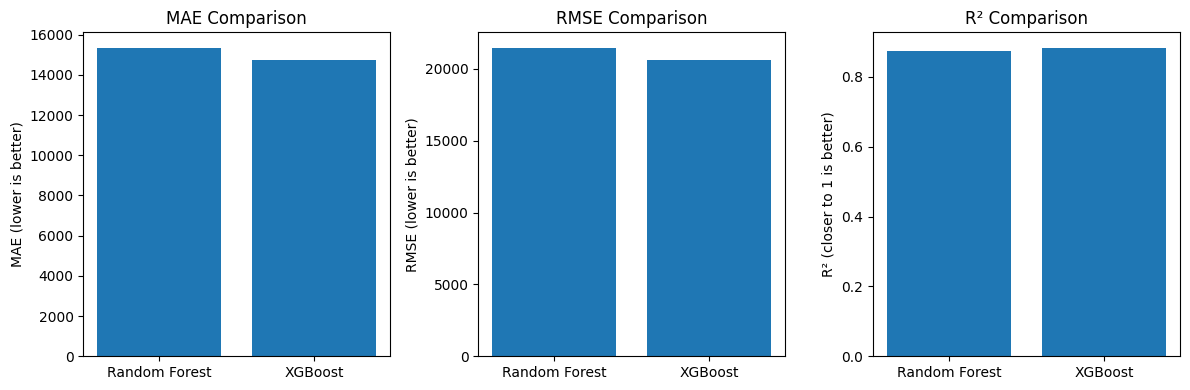

In [24]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'XGBoost']
mae_scores = [15349, 14751]
rmse_scores = [21477, 20640]
r2_scores = [0.8735, 0.8831]

plt.figure(figsize=(12, 4))

# MAE
plt.subplot(1, 3, 1)
plt.bar(models, mae_scores)
plt.title('MAE Comparison')
plt.ylabel('MAE (lower is better)')

# RMSE
plt.subplot(1, 3, 2)
plt.bar(models, rmse_scores)
plt.title('RMSE Comparison')
plt.ylabel('RMSE (lower is better)')

# R2
plt.subplot(1, 3, 3)
plt.bar(models, r2_scores)
plt.title('R² Comparison')
plt.ylabel('R² (closer to 1 is better)')

plt.tight_layout()
plt.show()


In [25]:
import joblib
joblib.dump(rf, "rf_model.pkl")
# Save model
joblib.dump(xgb, "xgb_model.pkl")


# Save column names for later inference
joblib.dump(X.columns.tolist(), "feature_names.pkl")


['feature_names.pkl']